In [3]:
import numpy as np
import pandas as pd
import nltk
import random
import matplotlib.pyplot as plt
import  SRToolkit.utils as utils
import ProGED as pg

In [ ]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0

    def best_child(self, c_param=1.4):
        log_parent = np.log(self.visits if self.visits > 0 else 1)

        def uct(c):
            if c.visits == 0:
                return float('inf')
            exploitation = c.value / c.visits
            exploration = c_param * np.sqrt(log_parent / c.visits)
            return exploitation + exploration
        
        return max(self.children, key=uct)


class mcts:
    def __init__(self, grammar, first_element, reward, max_rollout_depth=100):
        self.grammar = grammar
        self.first_element = first_element
        self.rules = self.grammar.productions()
        self.max_depth = max_rollout_depth
        self.reward = reward
        self.rollout_results = []

    def get_leftmost_nt(self, state):
        for index, symbol in enumerate(state):
            if isinstance(symbol, nltk.grammar.Nonterminal):
                return index, symbol
        return None, None

    def is_terminal(self, state):
        index, _ = self.get_leftmost_nt(state)
        return index is None

    def search(self, iterations):
        root = MCTSNode([nltk.grammar.Nonterminal(self.first_element)])
        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)
    
        return self.rollout_results


    def tree_policy(self, node):
        #TODO morda dodati epsilon greedy strategijo 
        while not self.is_terminal(node.state):
            index, nt = self.get_leftmost_nt(node.state)
            applicable = [r for r in self.rules if r.lhs() == nt]

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,index)
            
            node = node.best_child()
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        
        for prod in applicable:
            if prod not in tried:
                new_state = list(node.state)
                new_state[index:index+1] = list(prod.rhs())
                new_node = MCTSNode(new_state, node, prod, node.depth + 1)
                node.children.append(new_node)
                return new_node
        return node
    

    def simulate(self, node):

        current_state = list(node.state)
        depth = node.depth

        while not self.is_terminal(current_state) and depth < self.max_depth:
  
            index, nt = self.get_leftmost_nt(current_state)
            rules = [r for r in self.rules if r.lhs() == nt]
            probs = [r.prob() for r in rules]
            selected = random.choices(rules, weights=probs, k=1)[0]
            current_state[index:index+1] = list(selected.rhs())
            depth += 1
        

        if not self.is_terminal(current_state):
            print("warning: reached max depth without terminal state")
            return 0.0

        state_string = "".join(str(t) for t in current_state)
        reward = self.reward(state_string)
        self.rollout_results.append((state_string, reward))
        return reward

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent


In [89]:
def mc_search(grammar, iterations, utility):
    results = []
    for i in range(iterations):
        state = utils.generate_from_pcfg(grammar)
        reward = utility(state)
        state_string = "".join(str(t) for t in state)
        results.append((state_string, reward))
    return results

In [90]:
# za zacetek vzamemo 3

p_a = 0.1
p_b = 0.9
p_c = 0.9

grammar = f"""
    E -> A B C [1.0]
    
    A -> A'a' [{p_a}]
    A -> 'a'   [{1 - p_a}]
    
    B -> B'b' [{p_b}]
    B -> 'b'   [{1 - p_b}]
    
    C -> C'c' [{p_c}]
    C -> 'c'   [{1 - p_c}]
"""

def gini_impurity(expr):
    return 1 - sum(expr.count(c)**2 for c in set(expr))/len(expr)**2

nltk_grammar = nltk.grammar.PCFG.fromstring(grammar)
mcts = mcts(nltk_grammar, first_element="E", reward=gini_impurity, max_rollout_depth=100)
results_mcts = mcts.search(1000)
results_mc = mc_search(grammar, 1000, gini_impurity)
results_mcts


[('aabbbbbbbccccc', 0.6020408163265306),
 ('aabccccccccccccccccccccccccccccc', 0.173828125),
 ('abbbbcccccccc', 0.5207100591715976),
 ('abbbbbbbbbbbbbbbbbbbbbbbbbbbbcccc', 0.2644628099173554),
 ('aaabbbbc', 0.59375),
 ('abcccccccc', 0.33999999999999997),
 ('aabbbbc', 0.5714285714285714),
 ('aaaabbbbbbbbbbbbbbbbbbbbbbbbbcccccccc', 0.48502556610664715),
 ('abcccc', 0.5),
 ('aabbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbc', 0.13492063492063489),
 ('abbbbc', 0.5),
 ('abc', 0.6666666666666667),
 ('aaabbbbccccccccccccccccccccccc', 0.3844444444444445),
 ('abbccccccccccc', 0.3571428571428571),
 ('aabcc', 0.64),
 ('abc', 0.6666666666666667),
 ('aaaaabbccccccccc', 0.5703125),
 ('abccccccccccccccc', 0.2145328719723183),
 ('aabcccccc', 0.49382716049382713),
 ('aaabbbbbbbbbbbbbbbbbbbbbbbbbcccccccccccccccccccccc', 0.5528),
 ('abbbbbbbbbbbbbbbbbbbbbccccccccccccc', 0.5012244897959184),
 ('aabbbbbbbbcc', 0.5),
 ('abbcccccccccc', 0.37869822485207105),
 ('aaaabccccccccccccccc', 0.395),
 ('abc', 0.666666666666

Izračunamo še  ``` drseče povprečje ```, da vidimo, koliko se model sploh uči.

In [ ]:
def plot_progress(results, name, window = 20):

    scores = [item[1] for item in results]
    max_scores = np.maximum.accumulate(scores)

    moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(10, 5))
    
    plt.scatter(range(len(scores)), scores, color='black', alpha=0.5, s=5, label='nagradna funkcija iteracije')
    plt.plot(range(len(max_scores)), max_scores, color='blue', linewidth=2, label='nagradna funkcija najboljšega rezultata')
    plt.plot(range(window-1, len(scores)), moving_avg, color='red', label='moving average')
    
    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('Funkcija nagrade')
    plt.legend()
    
    plt.show()


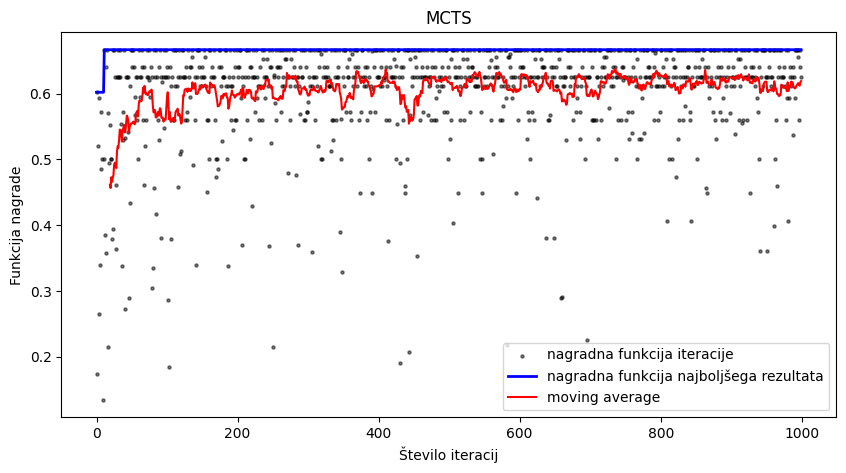

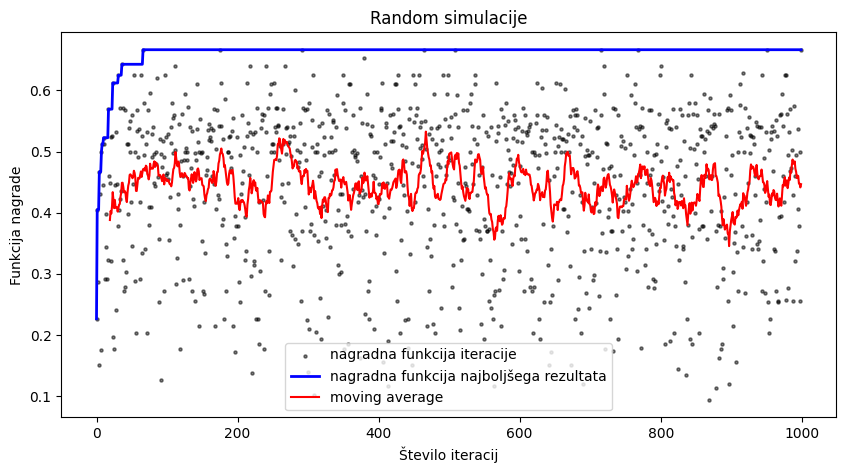

In [92]:
plot_progress(results_mcts, name="MCTS")
plot_progress(results_mc, name="Random simulacije")

Poizkus implementacije za enačbe:

In [4]:
from ProGED.parameter_estimation import Estimator                         
from ProGED.model_box import ModelBox
from ProGED.configs import settings

class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0
        if parent and applied_rule:
            self.log_prob = parent.log_prob + np.log(applied_rule.prob())
        else:
            self.log_prob = 0.0

    def best_child(self, c_param=1.4):
        log_parent = np.log(self.visits if self.visits > 0 else 1)

        def uct(c):
            if c.visits == 0:
                return float('inf')
            exploitation = c.value / c.visits
            exploration = c_param * np.sqrt(log_parent / c.visits)
            return exploitation + exploration
        
        return max(self.children, key=uct)


class MCTS_equation_discovery:
    def __init__(self, pg_grammar, first_element, reward, estimator, sym_vars, error = 1e-7, max_rollout_depth=100, c_param=1.4):
        self.grammar = pg_grammar
        self.first_element = first_element
        self.reward = reward
        self.estimator = estimator
        self.sym_vars = sym_vars
        self.rules = self.grammar.grammar.productions()
        self.error = error
        self.max_depth = max_rollout_depth
        self.best_model = None
        self.min_rmse = float('inf')
        self.history = []
        self.models = ModelBox()
        self.fitted_cache = {}
        self.n_points = len(self.estimator.data) if hasattr(self.estimator, 'data') else None
        self.c_param = c_param

    def get_leftmost_nt(self, state):
        for index, token in enumerate(state):
            if isinstance(token, nltk.grammar.Nonterminal):
                return index, token
        return None, None
    
    def is_terminal(self, state):
        index, _ = self.get_leftmost_nt(state)
        return index is None    
    
    def search(self, iterations):
        root = MCTSNode([nltk.grammar.Nonterminal(self.first_element)])
        root.log_prob = 0.0

        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)

            if self.min_rmse <= self.error:
                print(f"Stopping early at iteration {i} with RMSE {self.min_rmse}")
                return self.history, self.best_model, self.min_rmse
    
        print(f"Best model: {self.best_model} with RMSE: {self.min_rmse}" if self.best_model else "None")
        return self.history, self.best_model, self.min_rmse

    def tree_policy(self, node):
        while not self.is_terminal(node.state):
            index, nt = self.get_leftmost_nt(node.state)
            applicable = [r for r in self.rules if r.lhs() == nt]

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,index)
            
            node = node.best_child(c_param=self.c_param)
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        
        for prod in applicable:
            if prod not in tried:
                new_state = list(node.state)
                new_state[index:index+1] = list(prod.rhs())
                new_node = MCTSNode(new_state, node, prod, node.depth + 1)
                node.children.append(new_node)
                return new_node
        return node
    
    def simulate(self, node):
        current_state = list(node.state)
        depth = node.depth
        rollout_log_prob = node.log_prob

        while not self.is_terminal(current_state) and depth < self.max_depth:
            index, nt = self.get_leftmost_nt(current_state)
            rules = [r for r in self.rules if r.lhs() == nt]
            probs = [r.prob() for r in rules]
            selected = random.choices(rules, weights=probs, k=1)[0]
            rollout_log_prob += np.log(selected.prob())
            current_state[index:index+1] = list(selected.rhs())
            depth += 1
        
        if not self.is_terminal(current_state):
            print("Warning: reached max depth without terminal state")
            return 0.0

        state_str = "".join(str(t) for t in current_state)
        
        try:
            success, canonic_str = self.models.add_model(state_str, symbols={"x": self.sym_vars, "const": "C"}, lhs_vars=['y'])
            if not success:
                return 0.0
            
            if canonic_str in self.fitted_cache:
                self.history.append((canonic_str, self.fitted_cache[canonic_str][0], self.fitted_cache[canonic_str][1]))
                return self.fitted_cache[canonic_str][1]
            
            model = self.models.models_dict[canonic_str]
            fitted = self.estimator.fit_one(model)
            rmse = fitted.get_error()

            k_params = len(fitted.params)
            current_reward = self.reward(
                rmse=rmse,
                k=k_params +1, 
                n=self.n_points, 
                log_prob=rollout_log_prob
            )

            self.fitted_cache[canonic_str] = (rmse, current_reward)
            
            if rmse < self.min_rmse:
                self.min_rmse = rmse
                self.best_model = fitted

            self.history.append((canonic_str, rmse, current_reward))
            return current_reward
        
        except:
            print(f"Error occurred while fitting model for state: {state_str}")
            return 0.0


    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent

    def standard_mc(self, node, iterations):
        total_reward = 0.0
        for _ in range(iterations):
            reward = self.simulate(node)
            total_reward += reward

        average_reward = total_reward / iterations
        return average_reward


In [ ]:
def test_mcts():
    pass

In [6]:
settings["task_type"] = "algebraic"
settings["parameter_estimation"]["optimizer"] = "DE"
settings["lhs_vars"]= ["y"]
settings["parameter_estimation"]["param_bounds"] = [[-5, 5]]
settings["optimizer_DE"]["max_iter"] = 50 
settings["optimizer_DE"]["pop_size"] = 10
settings["parameter_estimation"]["max_constants"] = 5


In [9]:
variables = ["x1", "x2"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])
pg_grammar = pg.GeneratorGrammar(grammar)

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
df = pd.DataFrame(x_train, columns=variables)
df['y'] = (df['x2'])/(df['x1'])


# preprosta funkcija nagrade za testiranje (samo z napako RMSE)
def reward_rmse(*, rmse, **kwargs):
    return 1/(rmse + 1e-6)

est = Estimator(data=df, settings=settings)
mcts = MCTS_equation_discovery(pg_grammar, 'E', reward_rmse, est, variables, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(1000)
if best_model:
    print(f"Best model: {best_model.expr}")

Stopping early at iteration 591 with RMSE 0.0
Best model: [x2/x1]


In [14]:
variables = ["x1", "x2", "x3"]
grammar = "E -> E '+' T [0.4] | T [0.6]\n"
grammar += "T -> 'C' '*' V [0.7] | V [0.3]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])
pg_grammar = pg.GeneratorGrammar(grammar)

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
df = pd.DataFrame(x_train, columns=variables)
df['y'] = 2.5 * df['x1'] -2 * df['x2'] + 4 * df["x3"]

est = Estimator(data=df, settings=settings)
mcts = MCTS_equation_discovery(pg_grammar, 'E', reward_rmse, est, variables, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(1000)
if best_model:
    print(f"Best model: {best_model.expr}")

Best model: [2.49999165475592*x1 - 1.99999775239269*x2 + 3.99999307284925*x3] with RMSE: 3.183300783753283e-05
Best model: [C0*x1 + C1*x2 + C2*x3]


In [ ]:
vji = ["x1", "x2", "x3", "x4", "x5"]
x_train = np.random.uniform(-5, 5, (50, len(vji)))
df = pd.DataFrame(x_train, columns=vji)
df['y'] = df['x1'] - 3*df['x2'] - df['x3']-df["x5"]

grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(vji)}]" for v in vji])
pg_grammar = pg.GeneratorGrammar(grammar)

est = Estimator(data=df, settings=settings)
mcts = MCTS_equation_discovery(pg_grammar, 'E', reward_rmse, est, variables, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(500)

if best_model:
    print("\n--- FINAL RESULT ---")
    print(f"Target: y = x1 - 3*x2 - x3 - x5")
    print(f"MCTS Found: {best_model.expr}")
    print(f"RMSE: {best_rmse}")

Error occurred while fitting model for state: x4+x2


In [10]:
def reward_new(rmse, k,n,log_prob):
    log_posterior = - k/2 * np.log(n) + log_prob - n/2*np.log(2*np.pi) -n/2 - n*np.log(rmse)
    return 1/(1+abs(log_posterior))

In [15]:
mcts = MCTS_equation_discovery(pg_grammar, 'E', reward_new, est, variables, error=1e-9, max_rollout_depth=100)
results, best_model, best_rmse = mcts.search(1000)
if best_model:
    print(f"Best model: {best_model.expr}")
    print(f"Best RMSE: {best_rmse}")

Best model: [2.49999165475592*x1 - 1.99999775239269*x2 + 3.99999307284925*x3] with RMSE: 3.183300783753283e-05
Best model: [C0*x1 + C1*x2 + C2*x3]
Best RMSE: 3.183300783753283e-05


In [ ]:
def plot_progress_rmse(results, name, window=20):

    rmses = np.array([item[1] for item in results], dtype=float)
    best_rmse = np.minimum.accumulate(rmses)

        moving_avg = np.convolve(rmses, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))

    plt.scatter(range(len(rmses)), rmses, color='black', alpha=0.5, s=5, label='RMSE v iteraciji')
    plt.plot(range(len(best_rmse)), best_rmse, color='blue', linewidth=2, label='najmanjši RMSE do zdaj')

    # if len(rmses) >= window and window > 1:

    plt.plot(range(window-1, len(rmses)), moving_avg, color='red', label=f'moving average')

    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


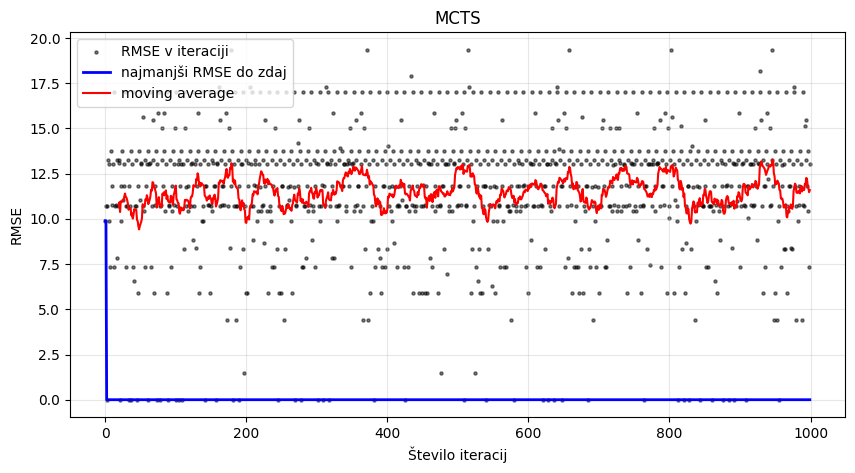

In [22]:
plot_progress_rmse(results, name="MCTS")